<a href="https://colab.research.google.com/github/Muktiprab007/ihsg-time-series-forecasting/blob/main/Explorasi_dataset_IHSG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

!pip install mplfinance
import mplfinance as mpf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 3.3 MB/s eta 0:00:00


# Dataset IHSG

Dataset ini berisi Harga historis harian IHSG (Indeks Harga Saham Gabungan) dari 02-01-1995 hingga 06-10-2025, atau yang juga dikenal sebagai Jakarta Composite Index (JCI). IHSG adalah indeks pasar saham utama Bursa Efek Indonesia (IDX) dan banyak digunakan sebagai tolok ukur untuk pasar ekuitas Indonesia.

Setiap baris mewakili satu hari perdagangan di Bursa Efek Indonesia (IDX).
Kolom: Date, Open, High, Low, Close.

1. **Date:** Menunjukkan tanggal berlangsungnya aktivitas perdagangan saham di IDX Composite atau IHSG. Kolom ini merepresentasikan hari ketika data indeks dicatat di Bursa Efek Indonesia. Jika pasar libur, biasanya tidak ada data untuk tanggal tersebut.

2. **Close:** Nilai akhir IHSG saat perdagangan ditutup pada hari tersebut. Angka ini sering dianggap paling penting karena mencerminkan posisi akhir pasar setelah seluruh transaksi selesai dan biasanya dipakai untuk analisis tren maupun perhitungan return harian.
3. **High:** Nilai tertinggi yang sempat dicapai IHSG selama satu hari perdagangan. Kolom ini menunjukkan titik maksimum pergerakan indeks sebelum pasar tutup, sehingga dapat menggambarkan seberapa kuat tekanan beli pada hari itu.

4. **Low:** Nilai terendah yang dicapai IHSG selama satu hari perdagangan. Angka ini menunjukkan titik minimum pergerakan indeks dan dapat digunakan untuk melihat seberapa besar tekanan jual atau penurunan pasar pada hari tersebut.

5. **Open:** Nilai IHSG ketika pasar pertama kali dibuka pada awal sesi perdagangan. Nilai ini menjadi acuan awal pergerakan indeks sebelum terjadi aktivitas jual beli sepanjang hari.

# Load Dataset

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/MutiaraCR/Dataset/refs/heads/main/ihsg_daily.csv")
df

,Date,Close,High,Low,Open
0,1/2/1995,470.121735,470.121735,470.121735,470.121735
1,1/3/1995,472.361633,472.361633,472.361633,472.361633
2,1/4/1995,474.471527,474.471527,474.471527,474.471527
3,1/5/1995,477.801422,477.801422,477.801422,477.801422
4,1/6/1995,481.201263,481.201263,481.201263,481.201263
...,...,...,...,...,...
7481,9/30/2025,8061.062012,8150.341797,8042.823242,8137.634766
7482,10/1/2025,8043.821777,8093.693848,8034.250000,8069.937012
7483,10/2/2025,8071.081055,8109.436035,8059.048828,8070.424805
7484,10/3/2025,8118.300781,8118.300781,8076.597168,8099.645020


In [ ]:
# Menjadikan DateTime sebagai index
df = df.set_index("Date")
df.index = pd.to_datetime(df.index)
df

,Close,High,Low,Open
Date,,,,
1995-01-02,470.121735,470.121735,470.121735,470.121735
1995-01-03,472.361633,472.361633,472.361633,472.361633
1995-01-04,474.471527,474.471527,474.471527,474.471527
1995-01-05,477.801422,477.801422,477.801422,477.801422
1995-01-06,481.201263,481.201263,481.201263,481.201263
...,...,...,...,...
2025-09-30,8061.062012,8150.341797,8042.823242,8137.634766
2025-10-01,8043.821777,8093.693848,8034.250000,8069.937012
2025-10-02,8071.081055,8109.436035,8059.048828,8070.424805


In [ ]:
df.describe()

,Close,High,Low,Open
count,7486.000000,7486.000000,7486.000000,7486.000000
mean,3254.782823,3273.411189,3234.235363,3255.135871
std,2487.921178,2500.587193,2476.075819,2489.317030
min,256.824036,261.303830,255.454079,257.513955
25%,618.008392,621.869823,613.702872,617.761178
50%,2829.974487,2847.447524,2797.120268,2830.076974
75%,5606.721070,5641.965820,5575.141601,5599.731445
max,8139.894043,8176.308105,8104.551758,8161.284180


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7486 entries, 1995-01-02 to 2025-10-06
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   7486 non-null   float64
 1   High    7486 non-null   float64
 2   Low     7486 non-null   float64
 3   Open    7486 non-null   float64
dtypes: float64(4)
memory usage: 292.4 KB


In [ ]:
df.isnull().sum()

,0
Close,0
High,0
Low,0
Open,0


In [ ]:
df.duplicated().sum()

np.int64(7)

In [ ]:
df[df.duplicated(keep=False)]

,Close,High,Low,Open
Date,,,,
1995-02-06,453.122375,453.122375,453.122375,453.122375
1995-02-17,453.122375,453.122375,453.122375,453.122375
2003-04-01,398.039490,398.039490,393.826672,397.026529
2003-04-02,398.039490,398.039490,393.826672,397.026529
2004-07-02,744.995972,744.995972,726.417656,728.547577
2004-07-05,744.995972,744.995972,726.417656,728.547577
2004-08-16,751.920715,754.769603,748.438856,754.339627
2004-08-17,751.920715,754.769603,748.438856,754.339627
2004-09-17,814.594299,814.594299,802.102781,812.921391


# Feature Engineering

In [ ]:
df2 = df.copy()
df2['Volatility_pct'] = ((df2['High'] - df2['Low']) / df2['Open']) * 100
df2['Return'] = ((df2['Close'] - df2['Open']) / df2['Open']) * 100

df2['MA_5'] = df2['Close'].rolling(window=5).mean()
df2['MA_10'] = df2['Close'].rolling(window=10).mean()
df2['EMA_5'] = df2['Close'].ewm(span=5, adjust=False).mean()
df2['EMA_10'] = df2['Close'].ewm(span=10, adjust=False).mean()

# RSI (Relative Strength Index)
window = 14
delta = df2['Close'].diff() # Selisih perubahan harga

# Gain dan Loss
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

# Average Gain dan Average Loss
avg_gain = gain.rolling(window=window).mean()
avg_loss = loss.rolling(window=window).mean()

# Relative Strength (RS)
rs = avg_gain / avg_loss

# RSI
df2['RSI_14'] = 100 - (100 / (1 + rs))

# MACD

# EMA cepat dan lambat
ema_12 = df2['Close'].ewm(span=12, adjust=False).mean()
ema_26 = df2['Close'].ewm(span=26, adjust=False).mean()

df2['MACD'] = ema_12 - ema_26 # MACD Line
df2['MACD_signal'] = df2['MACD'].ewm(span=9, adjust=False).mean() # Signal Line
df2['MACD_hist'] = df2['MACD'] - df2['MACD_signal'] # MACD Histogram

# STOCHASTIC OSCILLATOR
low_14 = df['Low'].rolling(window=14).min()
high_14 = df['High'].rolling(window=14).max()

# %K line
df2['Stochastic_%K'] = ((df2['Close'] - low_14) / (high_14 - low_14)) * 100

# %D line (moving average dari %K)
df2['Stochastic_%D'] = df2['Stochastic_%K'].rolling(window=3).mean()

df2

,Close,High,Low,Open,Volatility_pct,Return,MA_5,MA_10,EMA_5,EMA_10,RSI_14,MACD,MACD_signal,MACD_hist,Stochastic_%K,Stochastic_%D
Date,,,,,,,,,,,,,,,,
1995-01-02,470.121735,470.121735,470.121735,470.121735,0.000000,0.000000,NaN,NaN,470.121735,470.121735,NaN,0.000000,0.000000,0.000000,NaN,NaN
1995-01-03,472.361633,472.361633,472.361633,472.361633,0.000000,0.000000,NaN,NaN,470.868368,470.528989,NaN,0.178681,0.035736,0.142945,NaN,NaN
1995-01-04,474.471527,474.471527,474.471527,474.471527,0.000000,0.000000,NaN,NaN,472.069421,471.245814,NaN,0.484948,0.125579,0.359370,NaN,NaN
1995-01-05,477.801422,477.801422,477.801422,477.801422,0.000000,0.000000,NaN,NaN,473.980088,472.437743,NaN,0.985007,0.297464,0.687543,NaN,NaN
1995-01-06,481.201263,481.201263,481.201263,481.201263,0.000000,0.000000,475.191516,NaN,476.387146,474.031110,NaN,1.636778,0.565327,1.071451,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-30,8061.062012,8150.341797,8042.823242,8137.634766,1.321251,-0.940971,8090.172656,8070.083398,8080.613157,8048.429340,75.359051,99.620804,97.061191,2.559613,74.683272,84.327469
2025-10-01,8043.821777,8093.693848,8034.250000,8069.937012,0.736609,-0.323611,8073.625391,8071.947656,8068.349364,8047.591601,71.688428,93.071776,96.263308,-3.191532,66.899087,77.522489
2025-10-02,8071.081055,8109.436035,8059.048828,8070.424805,0.624344,0.008132,8079.708594,8078.212451,8069.259927,8051.862411,67.986034,89.054653,94.821577,-5.766924,65.001361,68.861240


* Volatility_pct : mengukur seberapa liar pergerakan harga


# Visualisasi

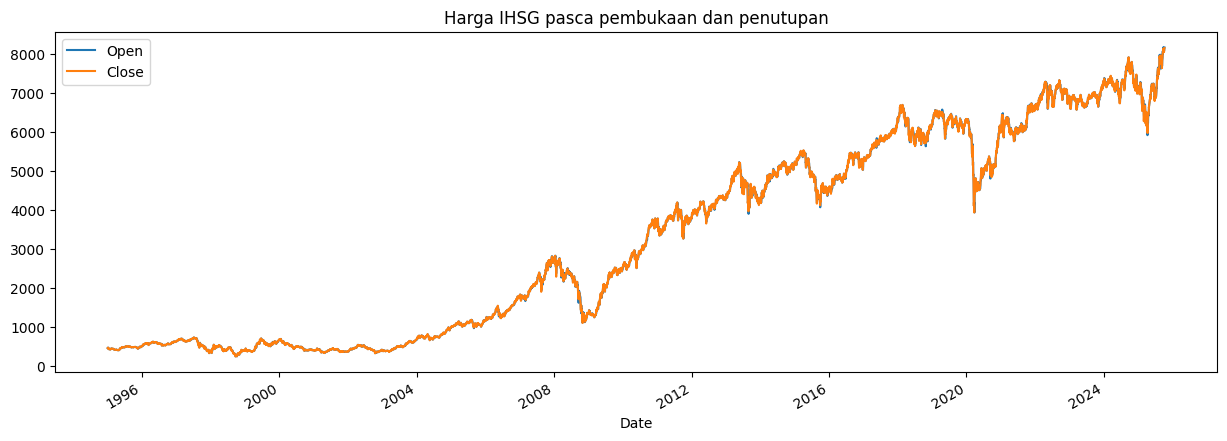

In [ ]:
df[["Open","Close"]].plot(style = "-", figsize = (15,5), title = "Harga IHSG pasca pembukaan dan penutupan")
plt.xlabel("Date")
plt.show()

<Axes: title={'center': 'Harga Penutupan Pasar IHSG 2025'}, xlabel='Date'>

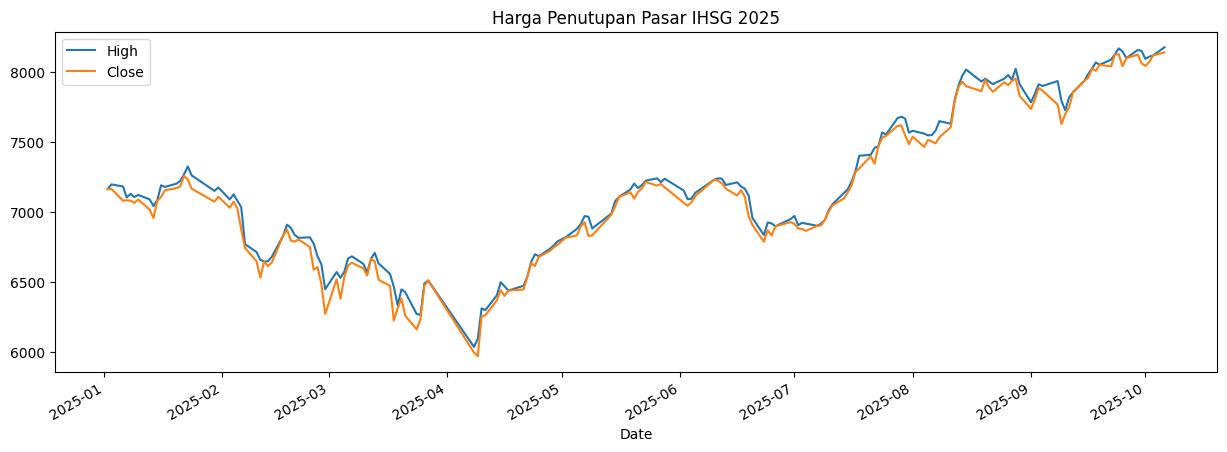

In [ ]:
df["2025-01-01" : "2025-10-06"][["High","Close"]].plot(style = "-", figsize = (15,5), title = "Harga Penutupan Pasar IHSG 2025")

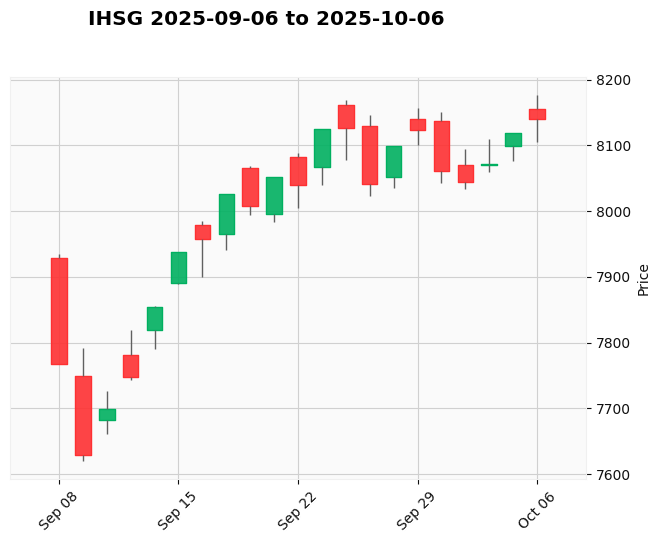

In [ ]:
df_one_month = df["2025-09-06" : "2025-10-06"]

mpf.plot(df_one_month, type='candle', style='yahoo', title='IHSG 2025-09-06 to 2025-10-06')

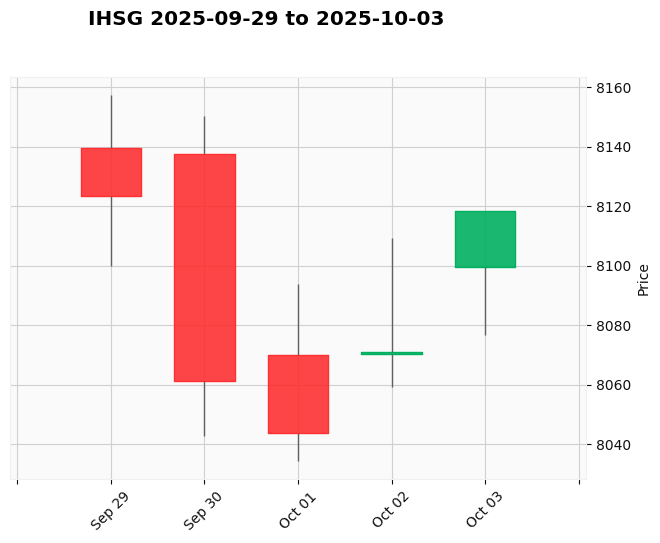

In [ ]:
df_one_month = df["2025-09-29" : "2025-10-03"]

mpf.plot(df_one_month, type='candle', style='yahoo', title='IHSG 2025-09-29 to 2025-10-03')

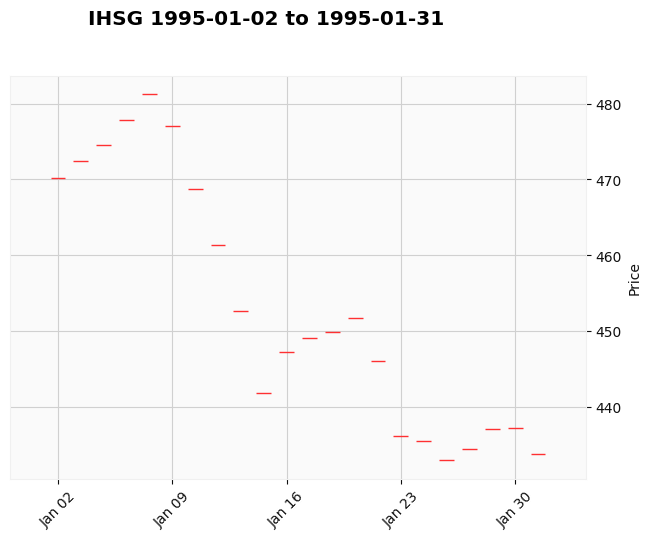

In [ ]:
df_one_month = df["1995-01-02" : "1995-01-31"]

mpf.plot(df_one_month, type='candle', style='yahoo', title='IHSG 1995-01-02 to 1995-01-31')

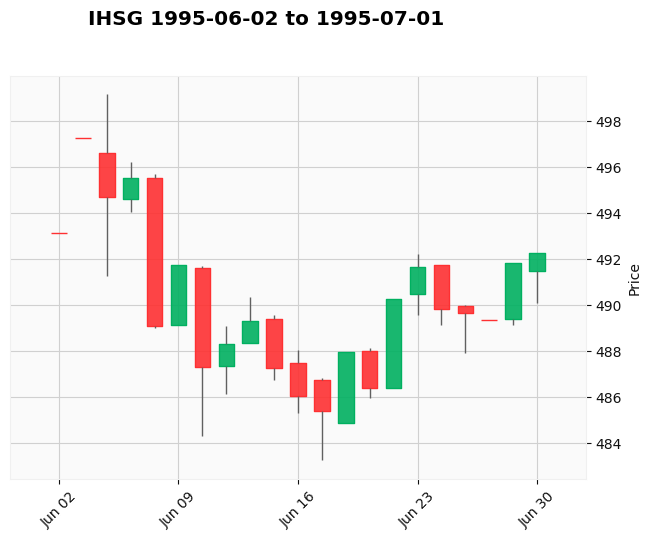

In [ ]:
df_one_month = df["1995-06-02" : "1995-07-01"]

mpf.plot(df_one_month, type='candle', style='yahoo', title='IHSG 1995-06-02 to 1995-07-01')

## Candlestick + MA + EMA

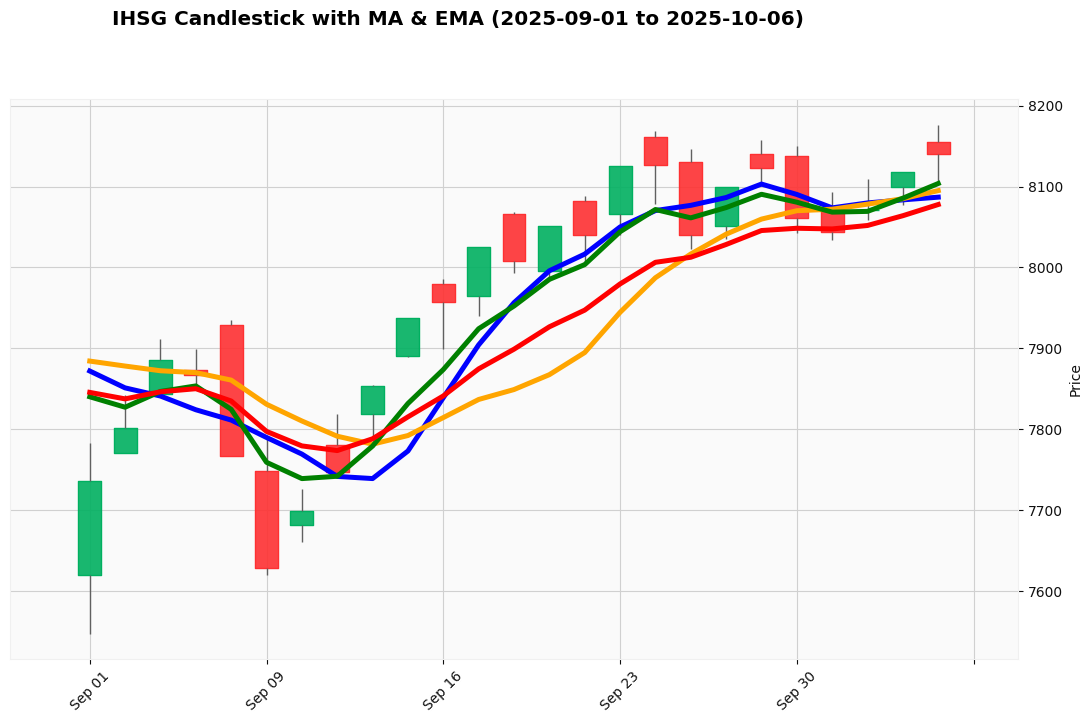

In [ ]:
df_one_last_month = df2['2025-09-01' : '2025-10-06']

apds_filtered = [
    mpf.make_addplot(df_one_last_month['MA_5'], color='blue'),
    mpf.make_addplot(df_one_last_month['MA_10'], color='orange'),
    mpf.make_addplot(df_one_last_month['EMA_5'], color='green'),
    mpf.make_addplot(df_one_last_month['EMA_10'], color='red')
]

mpf.plot(
    df_one_last_month,
    type='candle',
    style='yahoo',
    addplot=apds_filtered,
    volume=False,
    figsize=(14,8),
    title='IHSG Candlestick with MA & EMA (2025-09-01 to 2025-10-06)'
)

## VOLATILITY CHART

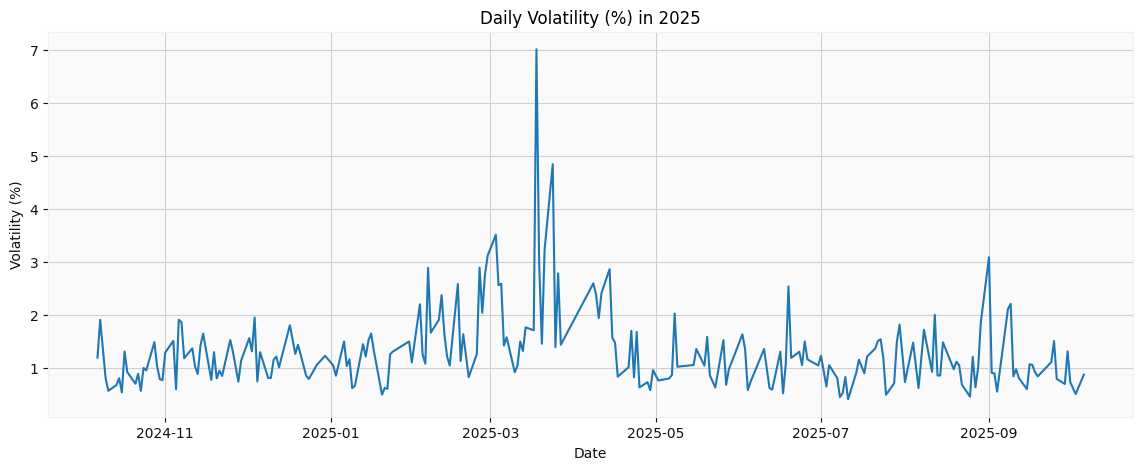

In [ ]:
df_one_last_year = df2['2024-10-06' : '2025-10-06']

plt.figure(figsize=(14,5))
plt.plot(df_one_last_year.index, df_one_last_year['Volatility_pct'])

plt.title('Daily Volatility (%) in 2025')
plt.xlabel('Date')
plt.ylabel('Volatility (%)')
plt.grid(True)

plt.show()

## Return Chart

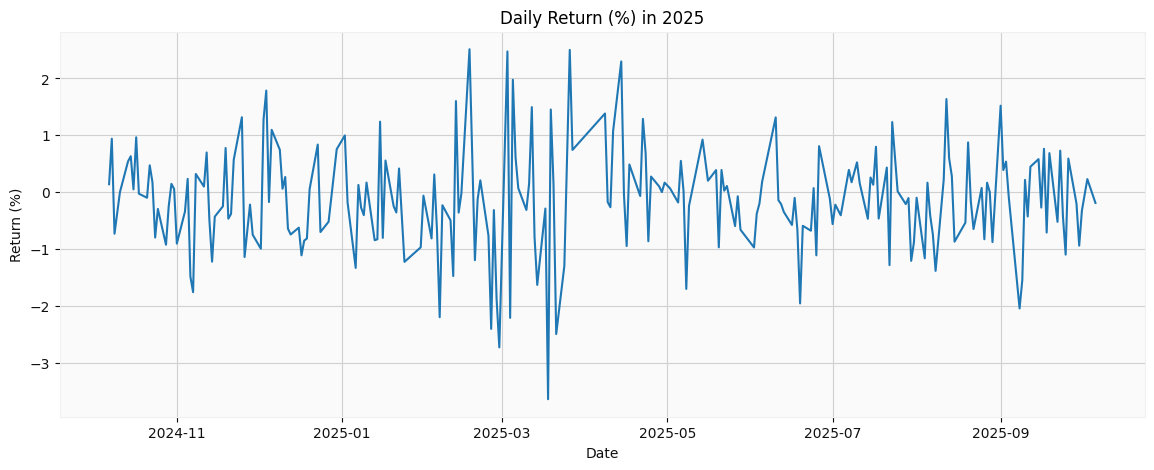

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(df_one_last_year.index, df_one_last_year['Return'])

plt.title('Daily Return (%) in 2025')
plt.xlabel('Date')
plt.ylabel('Return (%)')
plt.grid(True)

plt.show()

## Histogram Return

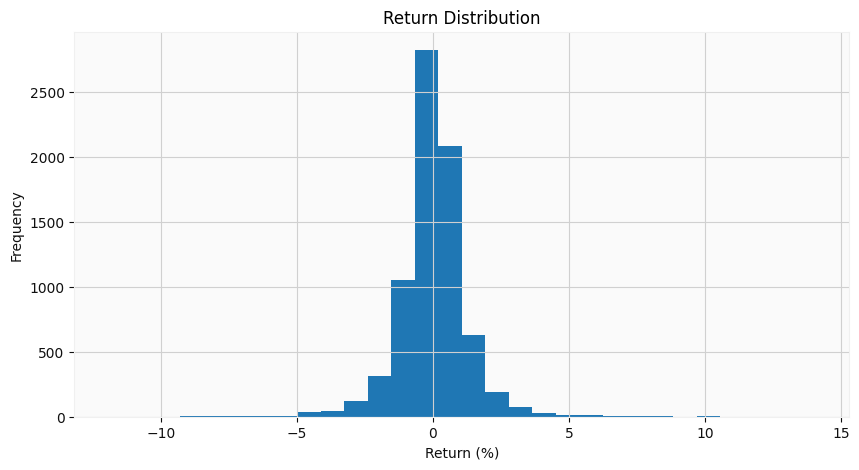

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(df2['Return'].dropna(), bins=30)

plt.title('Return Distribution')
plt.xlabel('Return (%)')
plt.ylabel('Frequency')

plt.show()

## RSI Chart

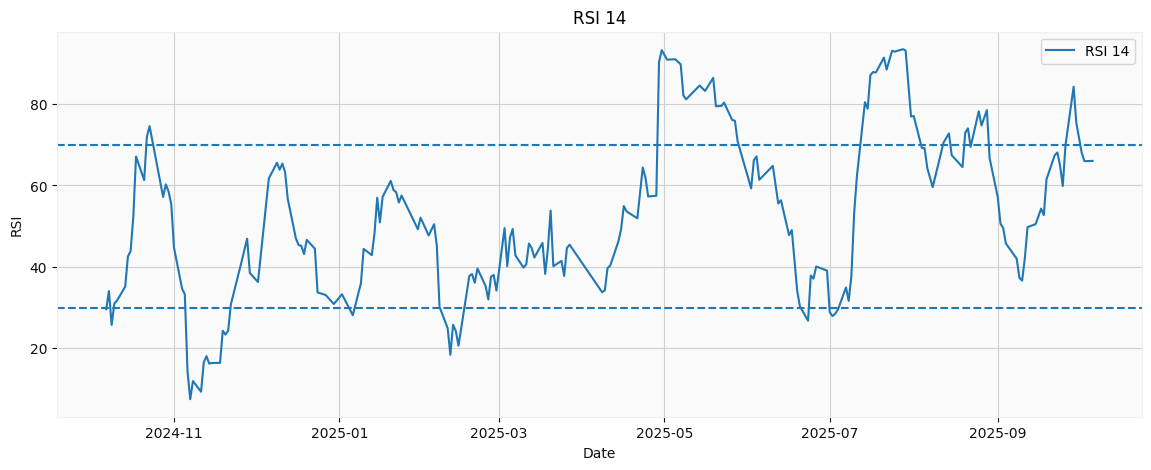

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(df_one_last_year.index, df_one_last_year['RSI_14'], label='RSI 14')

# Garis overbought & oversold
plt.axhline(70, linestyle='--')
plt.axhline(30, linestyle='--')

plt.title('RSI 14')
plt.xlabel('Date')
plt.ylabel('RSI')

plt.legend()
plt.grid(True)

plt.show()

## MACD Chart

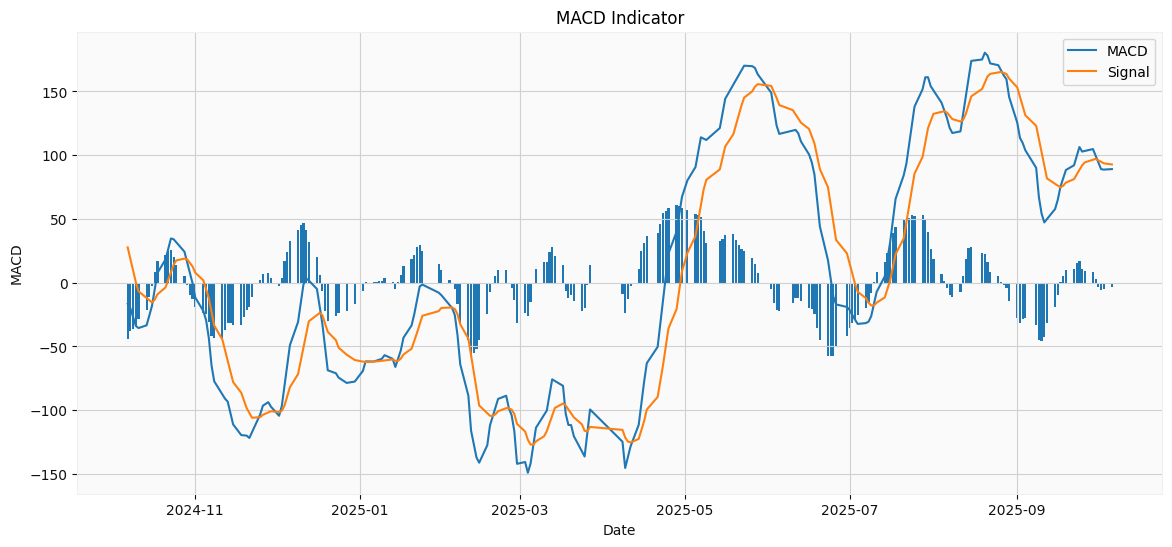

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(df_one_last_year.index, df_one_last_year['MACD'], label='MACD')
plt.plot(df_one_last_year.index, df_one_last_year['MACD_signal'], label='Signal')

# Histogram
plt.bar(df_one_last_year.index, df_one_last_year['MACD_hist'])

plt.title('MACD Indicator')
plt.xlabel('Date')
plt.ylabel('MACD')

plt.legend()
plt.grid(True)

plt.show()

## Stochastic Chart

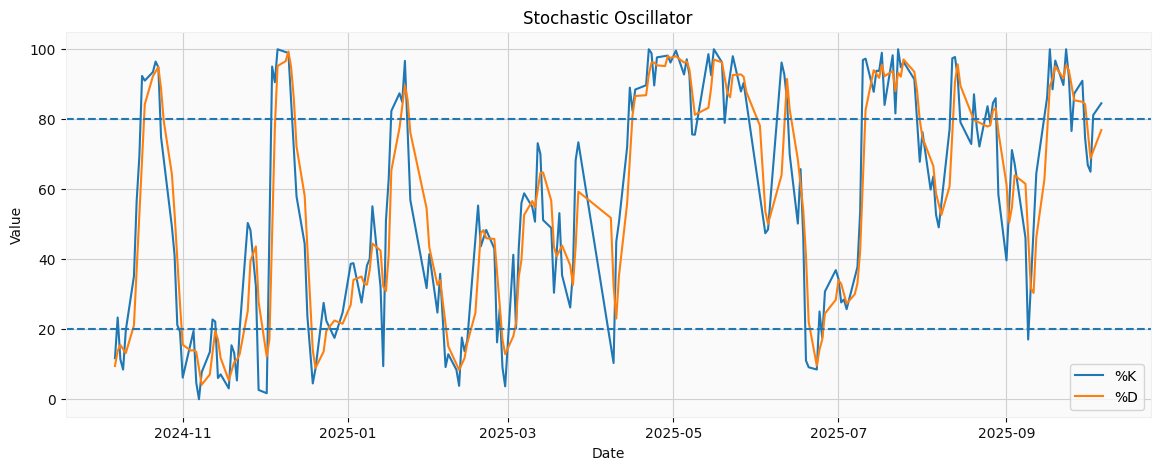

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(df_one_last_year.index, df_one_last_year['Stochastic_%K'], label='%K')
plt.plot(df_one_last_year.index, df_one_last_year['Stochastic_%D'], label='%D')

plt.axhline(80, linestyle='--')
plt.axhline(20, linestyle='o')

plt.title('Stochastic Oscillator')
plt.xlabel('Date')
plt.ylabel('Value')

plt.legend()
plt.grid(True)

plt.show()

## Correlation Heatmap

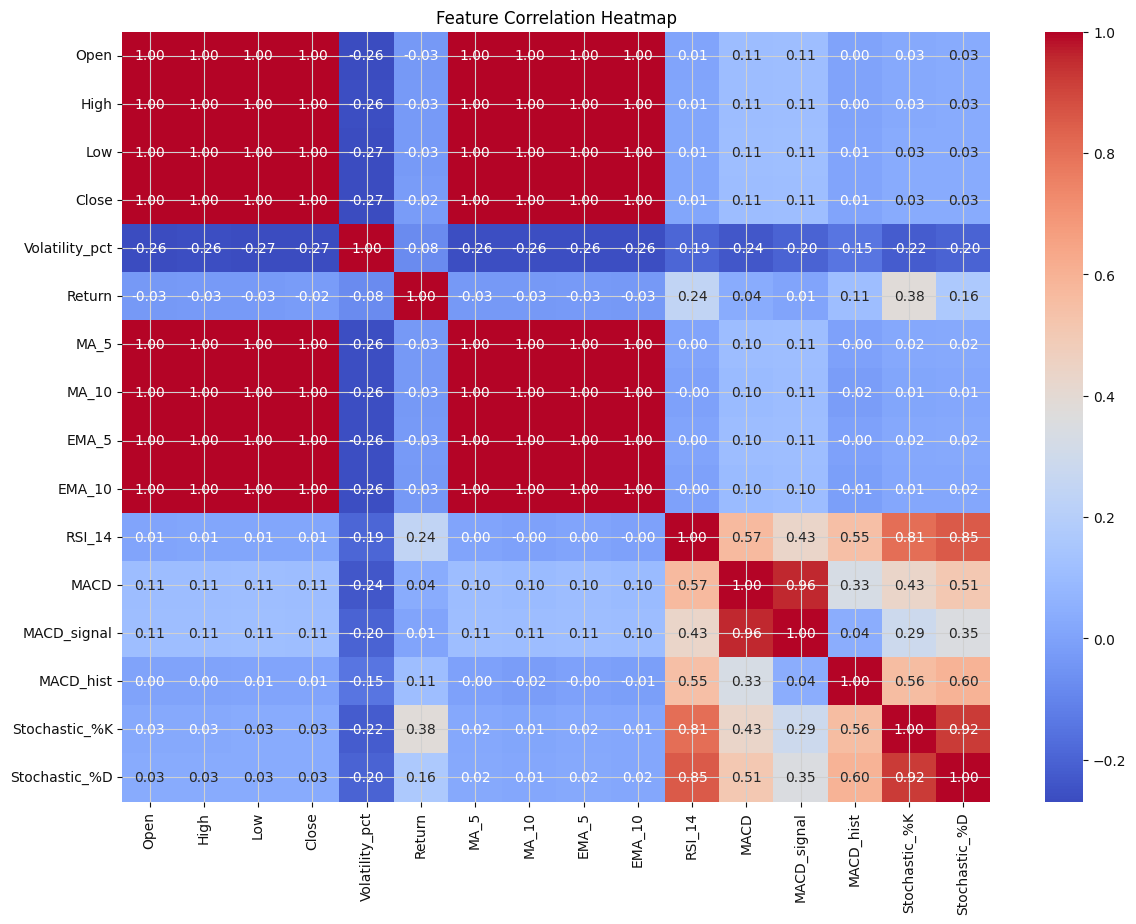

In [ ]:
features = [
    'Open',
    'High',
    'Low',
    'Close',
    'Volatility_pct',
    'Return',
    'MA_5',
    'MA_10',
    'EMA_5',
    'EMA_10',
    'RSI_14',
    'MACD',
    'MACD_signal',
    'MACD_hist',
    'Stochastic_%K',
    'Stochastic_%D'
]

corr = df2[features].corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Feature Correlation Heatmap')

plt.show()

# Export Data

In [ ]:
df3 = df2.copy()
df3 = df3.reset_index()
df3

,Date,Close,High,Low,Open,Volatility_pct,Return,MA_5,MA_10,EMA_5,EMA_10,RSI_14,MACD,MACD_signal,MACD_hist,Stochastic_%K,Stochastic_%D
0,1995-01-02,470.121735,470.121735,470.121735,470.121735,0.000000,0.000000,NaN,NaN,470.121735,470.121735,NaN,0.000000,0.000000,0.000000,NaN,NaN
1,1995-01-03,472.361633,472.361633,472.361633,472.361633,0.000000,0.000000,NaN,NaN,470.868368,470.528989,NaN,0.178681,0.035736,0.142945,NaN,NaN
2,1995-01-04,474.471527,474.471527,474.471527,474.471527,0.000000,0.000000,NaN,NaN,472.069421,471.245814,NaN,0.484948,0.125579,0.359370,NaN,NaN
3,1995-01-05,477.801422,477.801422,477.801422,477.801422,0.000000,0.000000,NaN,NaN,473.980088,472.437743,NaN,0.985007,0.297464,0.687543,NaN,NaN
4,1995-01-06,481.201263,481.201263,481.201263,481.201263,0.000000,0.000000,475.191516,NaN,476.387146,474.031110,NaN,1.636778,0.565327,1.071451,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7481,2025-09-30,8061.062012,8150.341797,8042.823242,8137.634766,1.321251,-0.940971,8090.172656,8070.083398,8080.613157,8048.429340,75.359051,99.620804,97.061191,2.559613,74.683272,84.327469
7482,2025-10-01,8043.821777,8093.693848,8034.250000,8069.937012,0.736609,-0.323611,8073.625391,8071.947656,8068.349364,8047.591601,71.688428,93.071776,96.263308,-3.191532,66.899087,77.522489
7483,2025-10-02,8071.081055,8109.436035,8059.048828,8070.424805,0.624344,0.008132,8079.708594,8078.212451,8069.259927,8051.862411,67.986034,89.054653,94.821577,-5.766924,65.001361,68.861240
7484,2025-10-03,8118.300781,8118.300781,8076.597168,8099.645020,0.514882,0.230328,8083.502148,8084.930713,8085.606879,8063.942115,65.964188,88.659283,93.589118,-4.929836,81.170791,71.023746


In [ ]:
df3.to_csv('ihsg_newdata.csv', index=True)

from google.colab import files
files.download('ihsg_newdata.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>